# 신경망 적용해보기

## MNIST
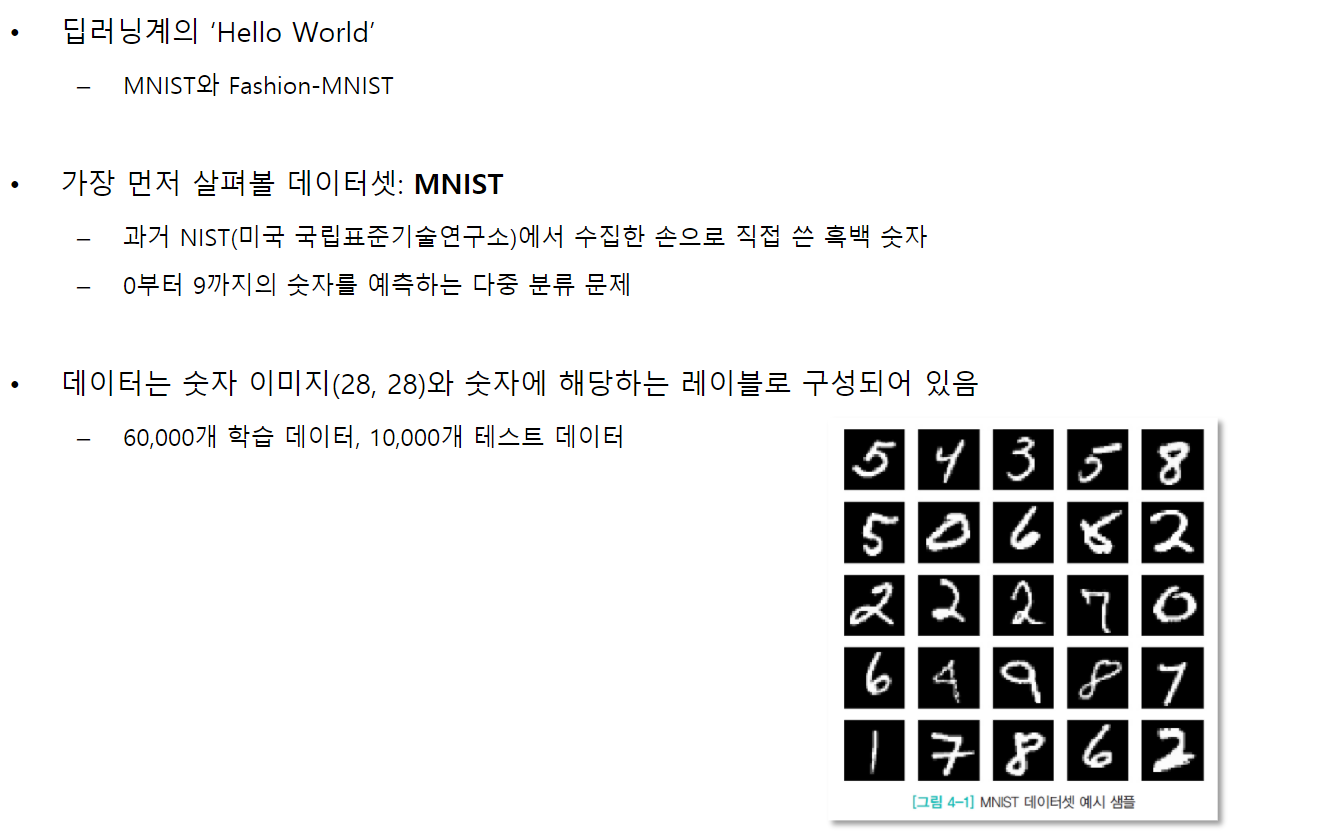

### MNIST 데이터셋 다운로드
- 케라스에서 제공하는 데이터셋은 전부 tf.keras.datasets를 통해 접근 가능   
- load_data() 함수는 (x_train, y_train), (x_test, y_test) 형태로 분할해서 제공


In [2]:
from tensorflow.keras.datasets import mnist
data= mnist.load_data()
len(data[0][0]), len(data[1][0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


(60000, 10000)

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

### 데이터 형태 확인
- 데이터, 레이블가 어떻게 구성되어 있는지 확인해보는 과정은
필수!
- 제공되는 코드를 통해 데이터를 그려보세요.


In [4]:
# 훈련 데이터
print(x_train.shape, y_train.shape)
print(y_train[:10])

(60000, 28, 28) (60000,)
[5 0 4 1 9 2 1 3 1 4]


In [5]:
# 테스트 데이터
print(x_test.shape, y_test.shape)
print(y_test[:10])

(10000, 28, 28) (10000,)
[7 2 1 0 4 1 4 9 5 9]


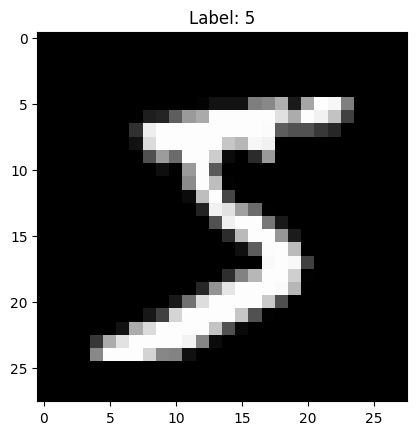

In [6]:
# 이미지 출력
import matplotlib.pyplot as plt

img = x_train[0]
label = y_train[0]

plt.figure()
plt.imshow(img, cmap='gray')
plt.title(f'Label: {label}')
plt.show()

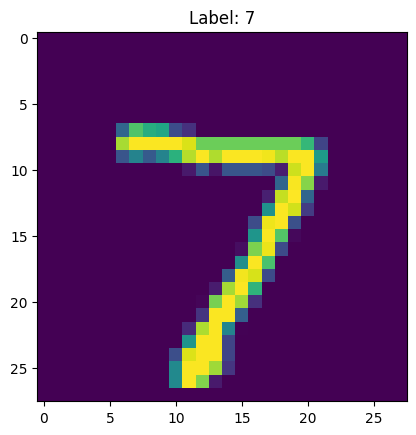

In [7]:
import matplotlib.pyplot as plt

img = x_test[0, :]
label = y_test[0]

plt.figure()
plt.imshow(img)
plt.title(f'Label: {label}')
plt.show()

In [8]:
for i in x_test[0]:
  for j in i:
    print(f'{j:4}', end='')
  print('\n')

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0  84 185 159 151  60  36   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0

   0   0   0   0   0   0 222 254 254 254 254 241 198 198 198 198 198 198 198 198 170  52

#### 모델 검증을 위해 검증 데이터셋을 만듭니다
- train_test_split() 함수 사용
- test_size: 테스트 데이터셋 비율
- random_state: 재생산성


In [9]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                                  test_size=0.2,
                                                  random_state=42)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)

(48000, 28, 28) (48000,)
(12000, 28, 28) (12000,)


#### 학습을 위해 전처리를 수행해야 함
- 255로 나눠주어 0~1사이로 스케일 조정
- 신경망은 스케일에 매우 민감!
- Dense 층 사용을 위해 784차원의 1차원 배열로 변환   
 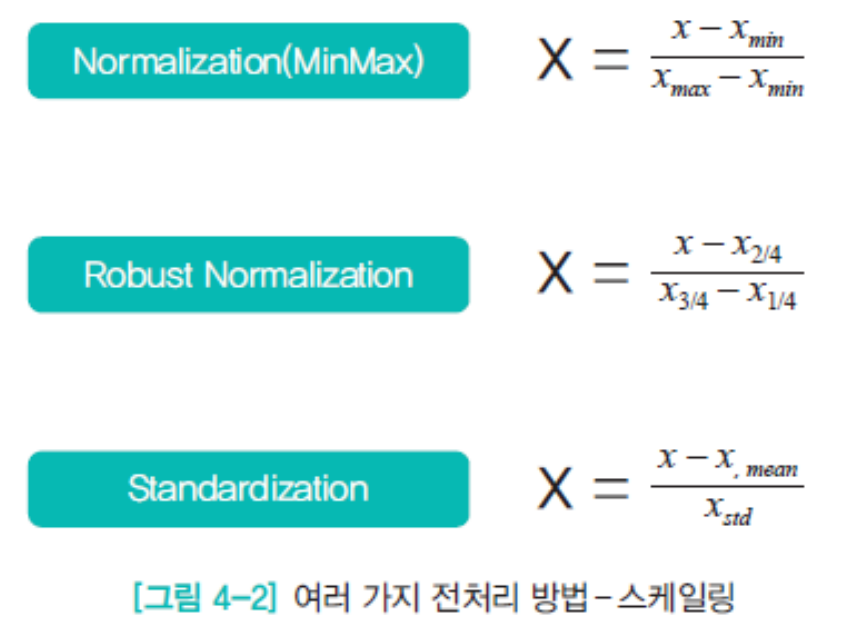


In [10]:
# 데이터 갯수
num_x_train = x_train.shape[0]
num_x_val = x_val.shape[0]
num_x_test = x_test.shape[0]

# 데이터 전처리(MinMax 적용)
x_train = (x_train.reshape((num_x_train, 28*28))) / 255
x_val = (x_val.reshape((num_x_val, 28*28))) / 255
x_test = (x_test.reshape((num_x_test, 28*28))) / 255

print(x_train.shape)

(48000, 784)


In [ ]:
print(x_train[0])

####  모델 입력을 위한 레이블 전처리

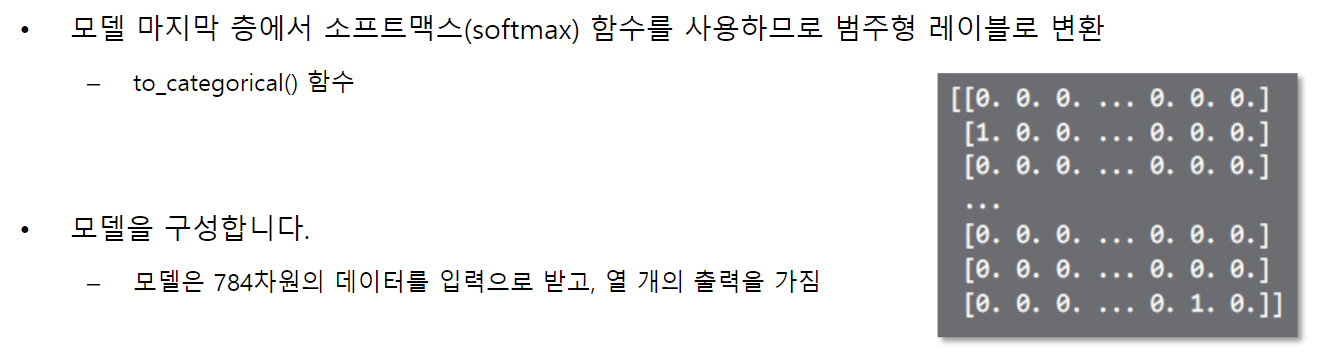

In [12]:
from tensorflow.keras.utils import to_categorical  # 원핫-인코딩

# 범주형 형식으로 변경
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]])

#### 모델 구성하기

##### 시그모이드, 소프트맥스 함수
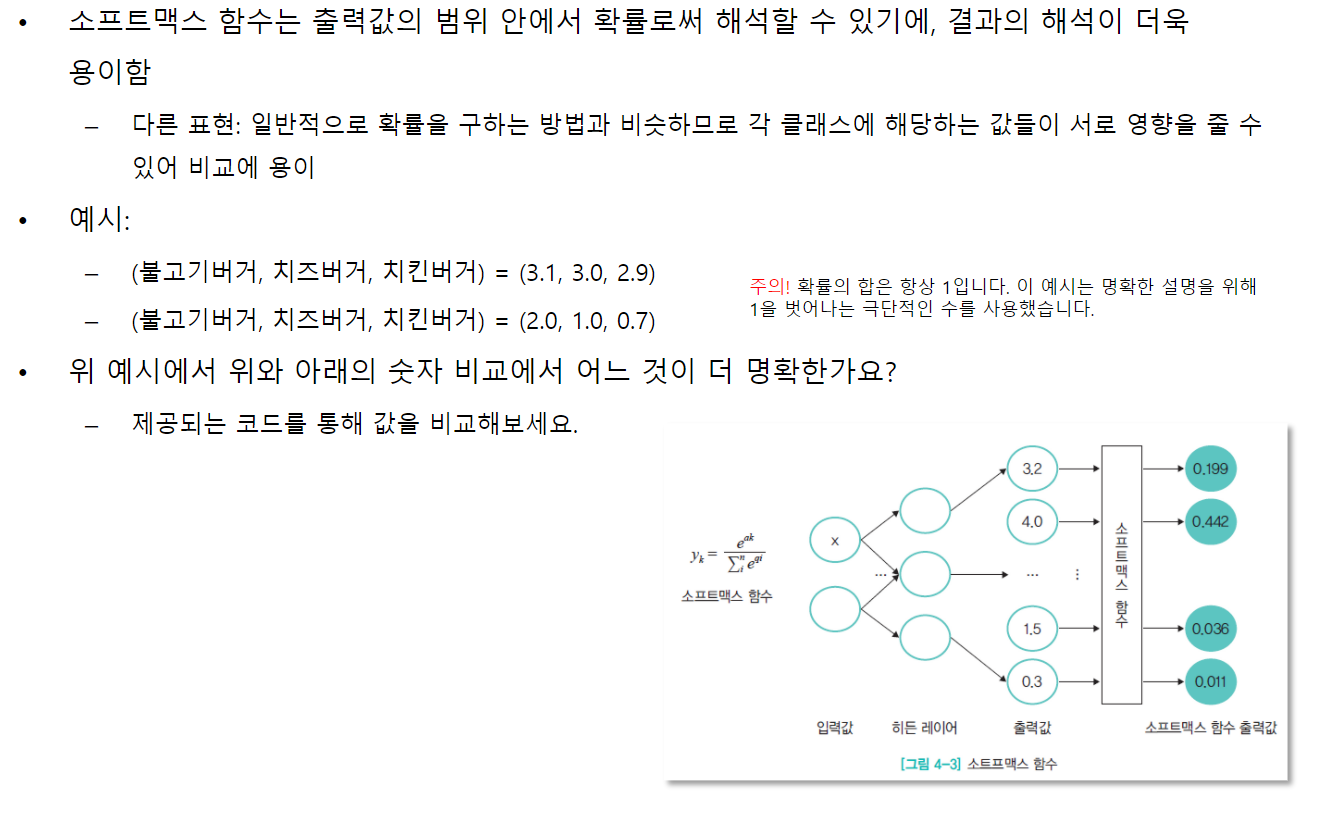

In [13]:
import numpy as np

# 소프트맥스 함수
def softmax(arr):
  max_arr = np.max(arr)
  arr = arr - max_arr # 오버플로우 방지
  arr = np.exp(arr)   # 자연로그 적용
  return arr / np.sum(arr)

# 시그모이드 함수
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

case_1 = np.array([3.1, 3.0, 2.9])
case_2 = np.array([2.0, 1.0, 0.7])

np.set_printoptions(precision=3) # numpy 소수점 제한
print(f'sigmoid {sigmoid(case_1)}, softmax {softmax(case_1)}')
print(f'sigmoid {sigmoid(case_2)}, softmax {softmax(case_2)}')

sigmoid [0.957 0.953 0.948], softmax [0.367 0.332 0.301]
sigmoid [0.881 0.731 0.668], softmax [0.61  0.224 0.166]


모델 생성하기

In [15]:
print(x_train[0].shape)

(784,)


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(784, )))
# => 784차원의 데이터 입력 => 64개의 출력값 생성
model.add(Dense(128, activation='relu')) # 입력: 64개, 출력:128
model.add(Dense(32, activation='relu')) # 입력: 128개, 출력:32
model.add(Dense(32, activation='relu')) # 입력: 32개, 출력:32
model.add(Dense(10, activation='softmax')) # 최종 10개의 출력

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 학습과정 설정하기

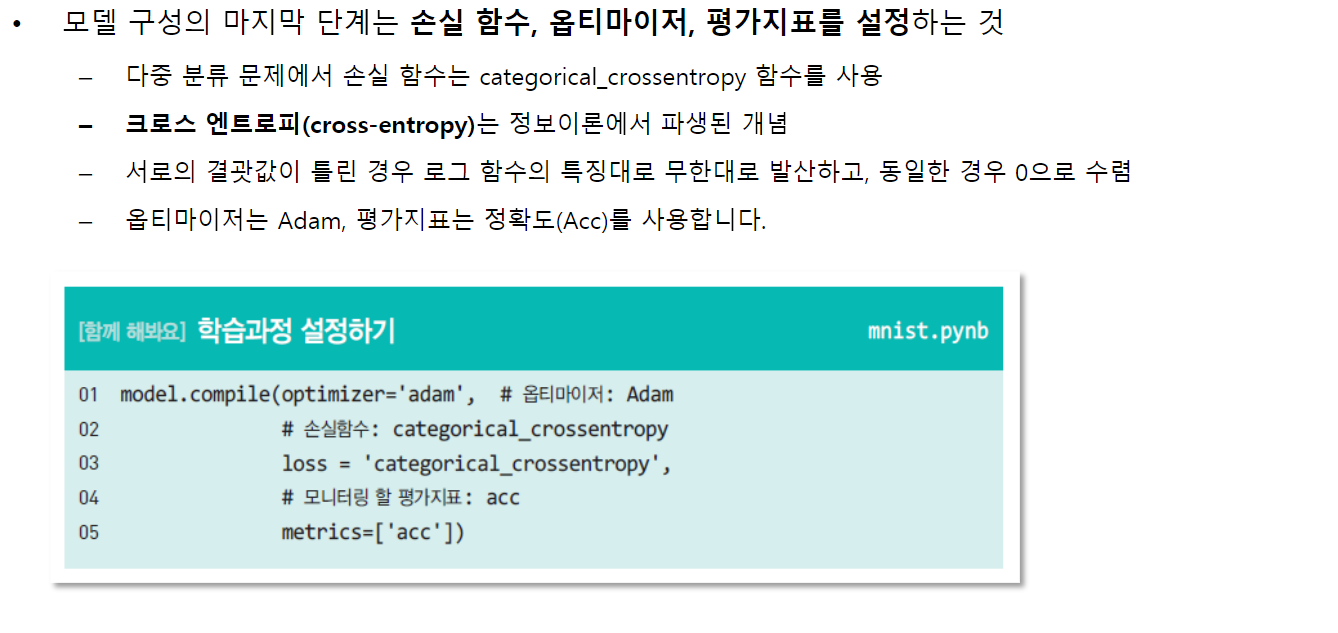

- 오티마이저(Optimizer)
    - 참조: https://yngie-c.github.io/deep%20learning/2020/03/19/training_techs/

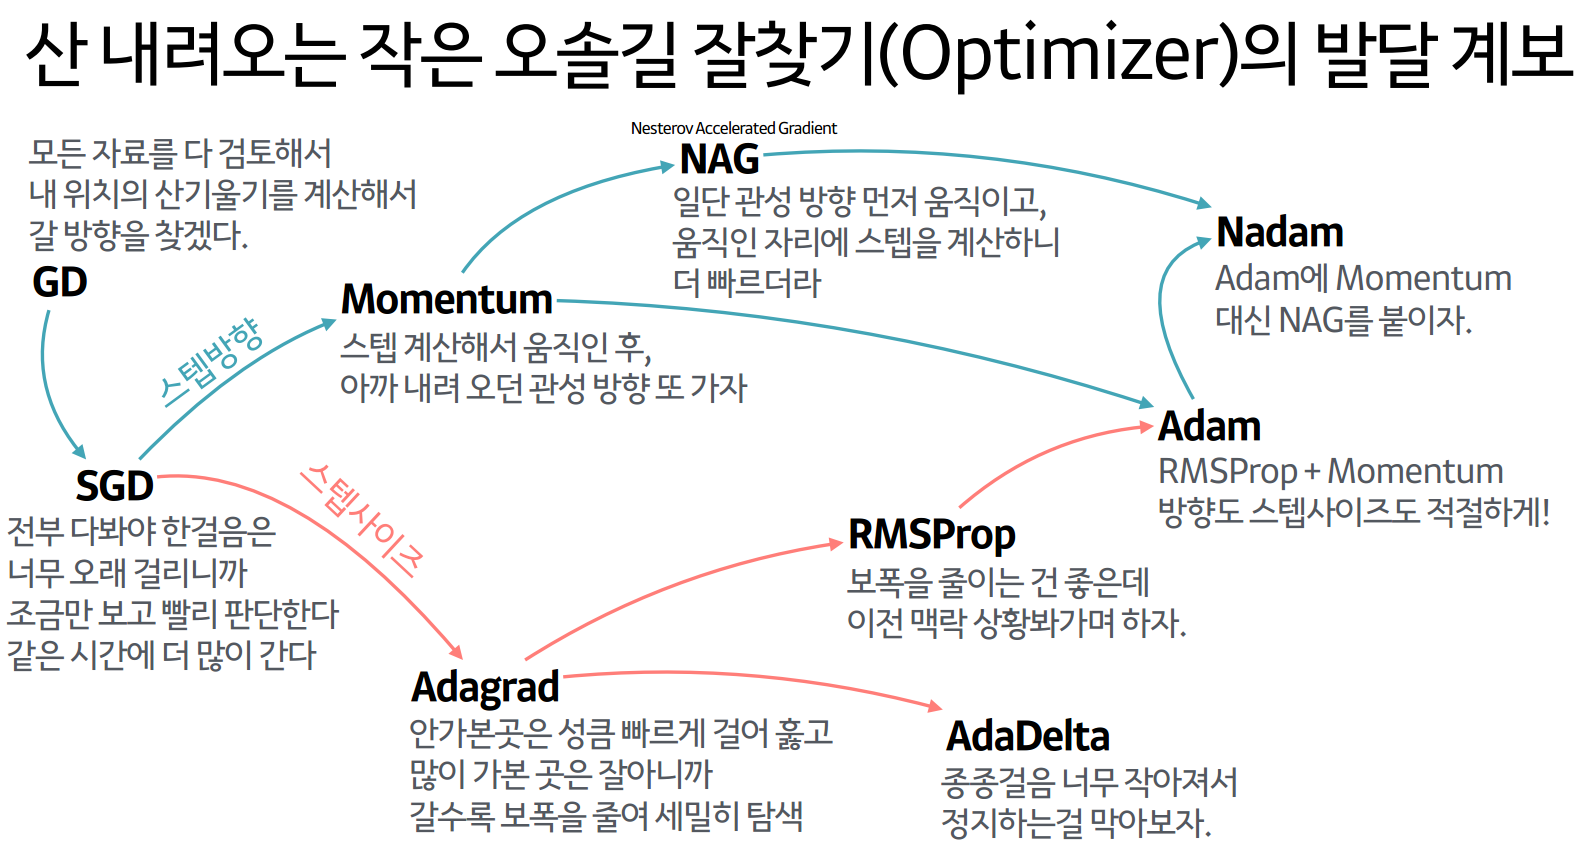

In [18]:
model.compile(optimizer='adam',   # 옵티마이져(adam: 스탭+방향)
              loss = 'categorical_crossentropy', # 손실함수
              metrics = ['acc'])  # 모니터리 평가 지표: 정확도


#### 모델 학습하기
- validation_data에 검증 데이터셋을 전달하고, 128 배치크기를 사용하며, 전체 데이터를 30회 반복

In [20]:
from sklearn.utils.validation import validate_data

history = model.fit(x_train, y_train,
                    epochs=30,
                    batch_size=128,
                    validation_data=(x_val, y_val))

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - acc: 0.7183 - loss: 0.8891 - val_acc: 0.9403 - val_loss: 0.2007
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9458 - loss: 0.1782 - val_acc: 0.9576 - val_loss: 0.1463
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9604 - loss: 0.1327 - val_acc: 0.9621 - val_loss: 0.1285
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - acc: 0.9699 - loss: 0.1016 - val_acc: 0.9632 - val_loss: 0.1215
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9732 - loss: 0.0864 - val_acc: 0.9640 - val_loss: 0.1183
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9798 - loss: 0.0646 - val_acc: 0.9705 - val_loss: 0.1027
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9823 - loss: 0.0567 - val_acc: 0.9703 - val_loss: 0.1054
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.9845 - loss: 0.0466 - val_acc: 0.9719 - val_loss: 0.0953
Epoch 9/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - ac

#### 학습 결과 그리기
- model.fit() 함수는 History 객체를 전달합니다. 이를 활용하여 학습 과정을 손쉽게 모니터링 할 수 있음

In [24]:
print(history.history)
print(history.history.keys())

{'acc': [0.8578541874885559, 0.9495833516120911, 0.9617916941642761, 0.9692708253860474, 0.9746041893959045, 0.9786249995231628, 0.9818750023841858, 0.9836458563804626, 0.9860416650772095, 0.9882500171661377, 0.9903333187103271, 0.9885833263397217, 0.992145836353302, 0.992562472820282, 0.9912083148956299, 0.9936875104904175, 0.9946249723434448, 0.9946041703224182, 0.9950833320617676, 0.9933541417121887, 0.9958750009536743, 0.9962708353996277, 0.9958541393280029, 0.996749997138977, 0.9960208535194397, 0.9957291483879089, 0.996666669845581, 0.9969791769981384, 0.9980000257492065, 0.9982708096504211], 'loss': [0.469618558883667, 0.1681336611509323, 0.12659643590450287, 0.10000423341989517, 0.08398012071847916, 0.06804674118757248, 0.057609084993600845, 0.05111999064683914, 0.04368840903043747, 0.03528066352009773, 0.02949972078204155, 0.03333456441760063, 0.023726381361484528, 0.02213483862578869, 0.02580607309937477, 0.019477708265185356, 0.016293127089738846, 0.015465779229998589, 0.013

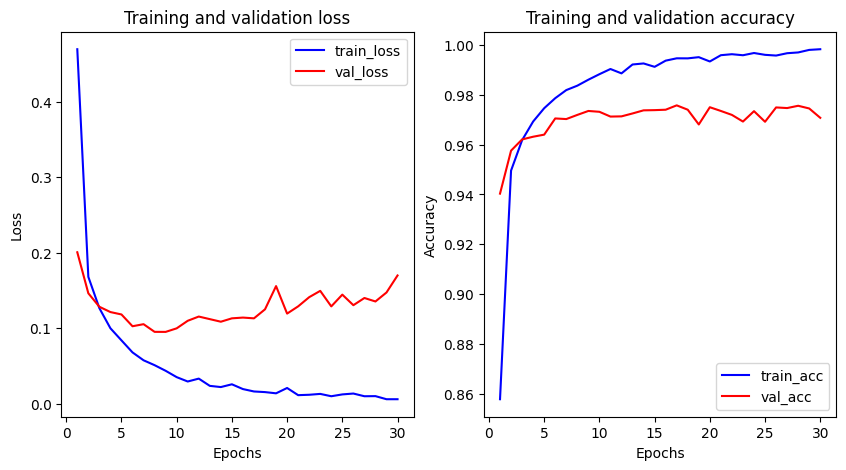

In [26]:
import matplotlib.pyplot as plt

his_dict = history.history

loss = his_dict['loss']          # 학습 데이터에 대한 loss
val_loss = his_dict['val_loss']  # 검증 데이터에 대한 loss

epochs = range(1, len(loss) + 1)

fig = plt.figure(figsize=(10, 5))

# 훈련 및 검증 손실 그래프
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(epochs, loss, color='blue', label='train_loss')
ax1.plot(epochs, val_loss, color='red', label='val_loss')
ax1.set_title('Training and validation loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# 훈련 및 검증 정확도 그래프
acc = his_dict['acc']
val_acc = his_dict['val_acc']

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(epochs, acc, color='blue', label='train_acc')
ax2.plot(epochs, val_acc, color='red', label='val_acc')
ax2.set_title('Training and validation accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

# 화면 출력
plt.show()



- 두 그래프가 어디서부터 벌어지나요?
  - 과대적합 문제가 나타난 것
  - 데이터 특성, 모델 구조 등을 수정해보고 재학습
  - 벌어지기 전까지의 모델을 사용하여 결과를 확인하고 이를 저장 및 기록


#### 모델 평가

In [27]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.9666 - loss: 0.2031


[0.17383021116256714, 0.9704999923706055]

#### 학습된 모델을 통해 값 예측하기

In [30]:
import numpy as np

np.set_printoptions(precision=7)  # 소수점 제안

y_pred = model.predict(x_test)

print(y_pred.shape)
print()
print(y_pred[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
(10000, 10)

[1.0481458e-17 2.3341211e-11 3.7271745e-16 7.8309069e-12 1.2893350e-13
 1.0715141e-15 3.3430837e-23 1.0000000e+00 8.4127364e-20 2.3028798e-14]


#### 예측값 그려서 확인해보기

In [32]:
# 예측값 중 가장 큰 값의 위치(index)를 가져와 출력
arg_result = np.argmax(y_pred, axis=1)
print(arg_result)

[7 2 1 ... 4 5 6]


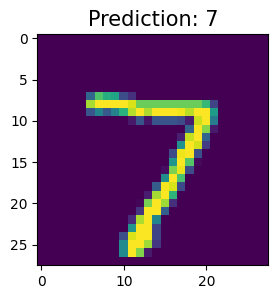

In [36]:
# 그래프로 그리기
import matplotlib.pyplot as plt

plt.figure(figsize=(3, 3))
plt.imshow(x_test[0].reshape(28, 28))
plt.title(f'Prediction: {arg_result[0]}', fontsize=15)
plt.show()

#### 모델 평가 방법 1 - 혼동 행렬

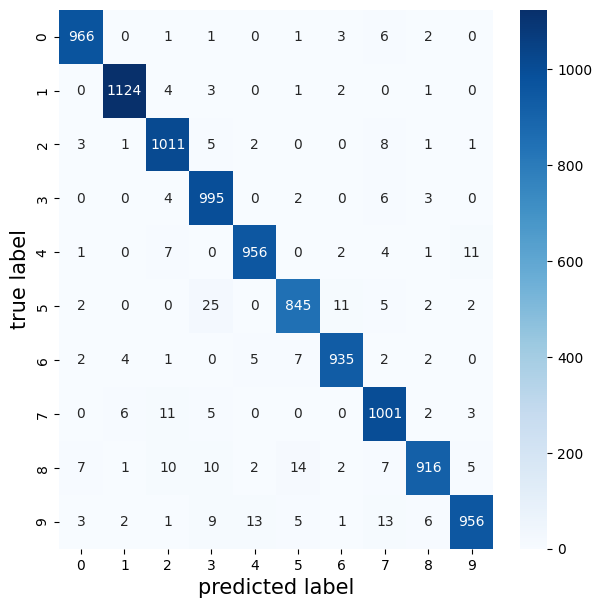

In [37]:
# sklearn.metrics 모듈은 여러가지 평가 지표에 관한 기능을 제공합니다.
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 혼동 행렬을 만듭니다.
plt.figure(figsize = (7, 7))
cm = confusion_matrix(np.argmax(y_test, axis = -1), np.argmax(y_pred, axis = -1))
sns.heatmap(cm, annot = True, fmt = 'd',cmap = 'Blues')
plt.xlabel('predicted label', fontsize = 15)
plt.ylabel('true label', fontsize = 15)
plt.show()

#### 모델 평가 방법 2 - 분류 보고서

In [39]:
print(classification_report(np.argmax(y_test, axis = -1), np.argmax(y_pred, axis = -1)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.94      0.99      0.96      1010
           4       0.98      0.97      0.98       982
           5       0.97      0.95      0.96       892
           6       0.98      0.98      0.98       958
           7       0.95      0.97      0.96      1028
           8       0.98      0.94      0.96       974
           9       0.98      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### 사용자 손글씨 적용해보기

1. 이미지 가져오기(흑백)

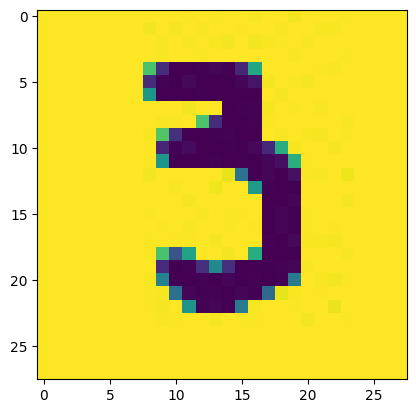

In [41]:
import cv2

img = cv2.imread('./userNum1.jpg', cv2.IMREAD_GRAYSCALE)
plt.imshow(img)
plt.show()

In [45]:
print(img.shape)
print(img[0])

(28, 28)
[255 255 255 255 255 255 255 255 255 255 255 254 255 254 255 255 253 255
 255 251 255 255 255 254 255 255 255 255]


2. 정규화(0~1 사이값으로 변경)

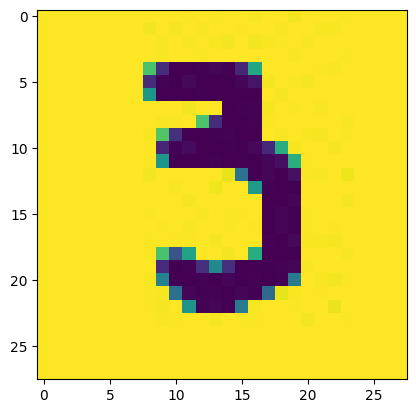

In [43]:
img_minmax = img / 255
plt.imshow(img_minmax)
plt.show()

In [46]:
print(img_minmax[0])

[1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.        1.        0.9960784 1.        0.9960784
 1.        1.        0.9921569 1.        1.        0.9843137 1.
 1.        1.        0.9960784 1.        1.        1.        1.       ]


3. 차원 확장

In [49]:
img_input = img_minmax.reshape(1, 28*28)
print(img_input.shape)

(1, 784)


4. 모델 예측

In [50]:
userPred = model.predict(img_input)
print(userPred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
[[0.0000000e+00 3.0753009e-28 0.0000000e+00 1.4041443e-11 8.6880505e-44
  1.0000000e+00 0.0000000e+00 6.2045870e-26 1.4012985e-45 6.0674713e-27]]


In [53]:
print(np.argmax(userPred))

5


### 모델 저장 및 불러오기

In [55]:
# model.save('./my_mnist_model.h5')
model.save('./my_mnist_model.keras')

In [57]:
from tensorflow.keras.models import load_model

# new_model = load_model('./my_mnist_model.h5')
new_model = load_model('./my_mnist_model.keras')

new_userNum = new_model.predict(img_input)
print(np.argmax(new_userNum))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
5
